# CodeGPT
- https://aclanthology.org/2023.ranlp-1.34.pdf
- https://huggingface.co/microsoft/CodeGPT-small-py

In [1]:
# 3 min installation
# pip install torch transformers pandas numpy scikit-learn matplotlib

from pathlib import Path
import pandas as pd
import numpy as np
import joblib, math, time

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


D:\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_PATH = Path('data')
PROCESSED_PATH = DATASET_PATH / 'processed'
MODELS_PATH = DATASET_PATH / 'models'
REPORTS_PATH = DATASET_PATH / 'reports'
EMBEDDINGS_PATH = DATASET_PATH / 'embeddings'

MODELS_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_PATH / '02_train_transformer.csv'
VAL_PATH = PROCESSED_PATH / '02_val_transformer.csv'

print('Train existe:', TRAIN_PATH.exists())
print('Val existe:', VAL_PATH.exists())

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print('Train:', train_df.shape)
print('Val:', val_df.shape)
display(train_df.head())

REPORT_PREFIX = "CodeGPT"
MODEL_NAME = 'microsoft/CodeGPT-small-py'


Train existe: True
Val existe: True
Train: (176, 7)
Val: (44, 7)


,pair_id,language,file_1,file_2,code_1_clean,code_2_clean,label
0,train_pair_000127,java,071.java,021.java,import java.io.*;\r\nimport java.net.*;\r\nimport java.util.*;\r\n\r\nimport javax.swing.text.html.*;\r\nimport java...,import java.util.*;\r\nimport java.net.*;\r\nimport java.io.*;\r\nimport misc.BASE64Encoder;\r\nimport javax.swing.*...,0
1,train_pair_000028,java,051.java,258.java,import java.io.*;\r\nimport java.net.*;\r\nimport java.*;\r\nimport java.Runtime.*;\r\nimport java.Object.*;\r\nimpo...,import java.awt.*;\r\nimport java.util.*;\r\nimport java.net.*;\r\nimport java.io.*;\r\nimport java.*;\r\n\r\npublic...,1
2,train_pair_000134,java,051.java,257.java,import java.io.*;\r\nimport java.net.*;\r\nimport java.*;\r\nimport java.Runtime.*;\r\nimport java.Object.*;\r\nimpo...,import java.awt.*;\r\nimport java.util.*;\r\nimport java.net.*;\r\nimport java.io.*;\r\nimport java.*;\r\n\r\npublic...,1
3,train_pair_000037,c,014.c,032.c,#include <stdio.h>\r\n#include <stdlib.h>\r\n#include <sys/time.h>\r\n#define MINCHAR 65\r\n#define MAXCHAR 122\r\n\...,"#include <stdio.h>\r\n#include <stdlib.h>\r\n#include <strings.h>\r\n#include <ctype.h>\r\n\r\nint (){\r\n\tsystem(""...",0
4,train_pair_000015,java,160.java,009.java,import java.io.*;\r\n\r\npublic class WatchDog\r\n{\r\npublic static void main (String[] args)\r\n{ String isd...,import java.util.*;\r\nimport java.text.*;\r\nimport java.io.*;\r\nimport java.*;\r\nimport java.net.*;\r\n\r\npubli...,0


In [3]:
required_cols = ['pair_id','language','file_1','file_2','code_1_clean','code_2_clean','label']
for name, df in [('train', train_df), ('val', val_df)]:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Faltan columnas en {name}: {missing}')

for df in [train_df, val_df]:
    df['code_1_clean'] = df['code_1_clean'].fillna('')
    df['code_2_clean'] = df['code_2_clean'].fillna('')
    df['label'] = df['label'].astype(int)

print('Train labels:')
display(train_df['label'].value_counts())
print('Val labels:')
display(val_df['label'].value_counts())
print('Lenguajes train:')
display(train_df['language'].value_counts())


Train labels:


label
0    88
1    88
Name: count, dtype: int64

Val labels:


label
1    22
0    22
Name: count, dtype: int64

Lenguajes train:


language
java    109
c        67
Name: count, dtype: int64

In [4]:
MAX_LENGTH = 256
BATCH_SIZE = 8

# Para usar todo deja None. Para prueba rápida usa, por ejemplo, 200 y 50.
MAX_ROWS_TRAIN = None
MAX_ROWS_VAL = None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

if MAX_ROWS_TRAIN is not None:
    train_df = train_df.sample(n=min(MAX_ROWS_TRAIN, len(train_df)), random_state=RANDOM_STATE).reset_index(drop=True)
if MAX_ROWS_VAL is not None:
    val_df = val_df.sample(n=min(MAX_ROWS_VAL, len(val_df)), random_state=RANDOM_STATE).reset_index(drop=True)

print('Train usado:', train_df.shape)
print('Val usado:', val_df.shape)


Device: cpu
Train usado: (176, 7)
Val usado: (44, 7)


In [5]:
# 3 minutes
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModel.from_pretrained(MODEL_NAME)
transformer_model.to(device)
transformer_model.eval()
print('Modelo cargado:', MODEL_NAME)


D:\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Usuario\.cache\huggingface\hub\models--microsoft--CodeGPT-small-py. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18858.25it/s]
[transformers] GPT2Model LOAD REPORT from: microsoft/CodeGPT-small-

Modelo cargado: microsoft/CodeGPT-small-py


In [6]:
@torch.no_grad()
def encode_texts(texts, tokenizer, model, max_length=256, batch_size=8, device='cpu'):
    embeddings_list = []
    n_batches = math.ceil(len(texts) / batch_size)
    for i in range(n_batches):
        batch = texts[i*batch_size:(i+1)*batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
        encoded = {k: v.to(device) for k, v in encoded.items()}
        outputs = model(**encoded)
        emb = outputs.last_hidden_state[:, 0, :]
        embeddings_list.append(emb.detach().cpu().numpy())
        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            print(f'Batch {i+1}/{n_batches}')
    return np.vstack(embeddings_list)


In [7]:
safe_model_name = MODEL_NAME.replace('/', '_').replace('-', '_')
cache_suffix = f'{safe_model_name}_len{MAX_LENGTH}'

train_emb1_path = EMBEDDINGS_PATH / f'{REPORT_PREFIX}_train_emb1_{cache_suffix}.npy'
train_emb2_path = EMBEDDINGS_PATH / f'{REPORT_PREFIX}_train_emb2_{cache_suffix}.npy'
val_emb1_path = EMBEDDINGS_PATH / f'{REPORT_PREFIX}_val_emb1_{cache_suffix}.npy'
val_emb2_path = EMBEDDINGS_PATH / f'{REPORT_PREFIX}_val_emb2_{cache_suffix}.npy'

use_cache = (
    MAX_ROWS_TRAIN is None and MAX_ROWS_VAL is None and
    train_emb1_path.exists() and train_emb2_path.exists() and val_emb1_path.exists() and val_emb2_path.exists()
)

if use_cache:
    print('Cargando embeddings desde cache...')
    train_emb_1 = np.load(train_emb1_path)
    train_emb_2 = np.load(train_emb2_path)
    val_emb_1 = np.load(val_emb1_path)
    val_emb_2 = np.load(val_emb2_path)
else:
    start = time.time()
    print('Train code 1')
    train_emb_1 = encode_texts(train_df['code_1_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    print('Train code 2')
    train_emb_2 = encode_texts(train_df['code_2_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    print('Val code 1')
    val_emb_1 = encode_texts(val_df['code_1_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    print('Val code 2')
    val_emb_2 = encode_texts(val_df['code_2_clean'].tolist(), tokenizer, transformer_model, MAX_LENGTH, BATCH_SIZE, device)
    print('Tiempo minutos:', round((time.time() - start)/60, 2))
    if MAX_ROWS_TRAIN is None and MAX_ROWS_VAL is None:
        np.save(train_emb1_path, train_emb_1)
        np.save(train_emb2_path, train_emb_2)
        np.save(val_emb1_path, val_emb_1)
        np.save(val_emb2_path, val_emb_2)

print(train_emb_1.shape, train_emb_2.shape, val_emb_1.shape, val_emb_2.shape)


Train code 1
Batch 10/22
Batch 20/22
Batch 22/22
Train code 2
Batch 10/22
Batch 20/22
Batch 22/22
Val code 1
Batch 6/6
Val code 2
Batch 6/6
Tiempo minutos: 3.32
(176, 768) (176, 768) (44, 768) (44, 768)


In [8]:
def rowwise_cosine(a, b):
    num = np.sum(a * b, axis=1)
    den = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    den = np.where(den == 0, 1e-8, den)
    return num / den

def build_embedding_features(emb1, emb2):
    abs_diff = np.abs(emb1 - emb2)
    product = emb1 * emb2
    cos = rowwise_cosine(emb1, emb2).reshape(-1, 1)
    return np.hstack([emb1, emb2, abs_diff, product, cos])

X_train = build_embedding_features(train_emb_1, train_emb_2)
X_val = build_embedding_features(val_emb_1, val_emb_2)
y_train = train_df['label'].values
y_val = val_df['label'].values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)


X_train: (176, 3073)
X_val: (44, 3073)


In [9]:
def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    result = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': cm[0,0] if cm.shape == (2,2) else np.nan,
        'fp': cm[0,1] if cm.shape == (2,2) else np.nan,
        'fn': cm[1,0] if cm.shape == (2,2) else np.nan,
        'tp': cm[1,1] if cm.shape == (2,2) else np.nan,
    }
    print('=====', model_name, '=====')
    print('Accuracy :', round(result['accuracy'], 4))
    print('Precision:', round(result['precision'], 4))
    print('Recall   :', round(result['recall'], 4))
    print('F1-score :', round(result['f1'], 4))
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, zero_division=0))
    print('Matriz de confusión:')
    print(cm)
    return result

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No reuso','Reuso'])
    ax.set_yticklabels(['No reuso','Reuso'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i,j], ha='center', va='center')
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()


===== Embedding Logistic Regression =====
Accuracy : 0.8409
Precision: 0.8261
Recall   : 0.8636
F1-score : 0.8444

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        22
           1       0.83      0.86      0.84        22

    accuracy                           0.84        44
   macro avg       0.84      0.84      0.84        44
weighted avg       0.84      0.84      0.84        44

Matriz de confusión:
[[18  4]
 [ 3 19]]


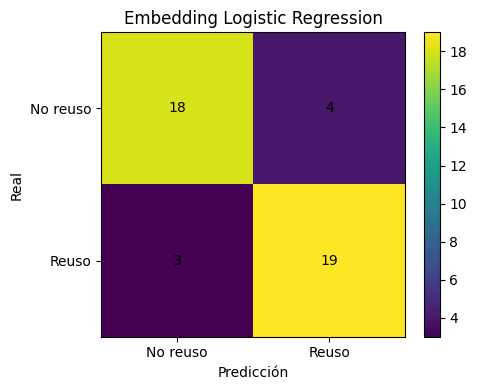

===== Embedding Linear SVM =====
Accuracy : 0.8182
Precision: 0.7917
Recall   : 0.8636
F1-score : 0.8261

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        22
           1       0.79      0.86      0.83        22

    accuracy                           0.82        44
   macro avg       0.82      0.82      0.82        44
weighted avg       0.82      0.82      0.82        44

Matriz de confusión:
[[17  5]
 [ 3 19]]


D:\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


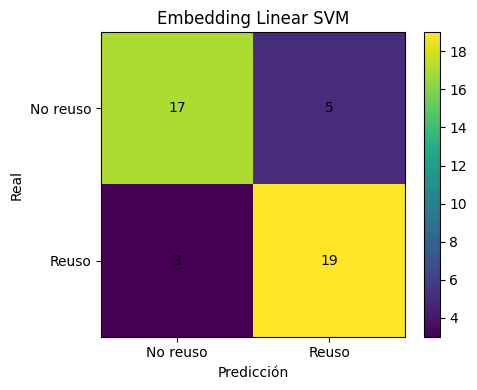

===== Embedding Random Forest =====
Accuracy : 0.8182
Precision: 0.7917
Recall   : 0.8636
F1-score : 0.8261

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        22
           1       0.79      0.86      0.83        22

    accuracy                           0.82        44
   macro avg       0.82      0.82      0.82        44
weighted avg       0.82      0.82      0.82        44

Matriz de confusión:
[[17  5]
 [ 3 19]]


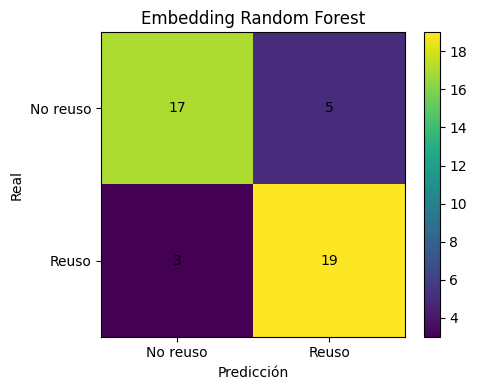

In [10]:
results = []

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_val)
results.append(evaluate_model('Embedding Logistic Regression', y_val, pred_lr))
plot_cm(y_val, pred_lr, 'Embedding Logistic Regression')

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000))
])
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_val)
results.append(evaluate_model('Embedding Linear SVM', y_val, pred_svm))
plot_cm(y_val, pred_svm, 'Embedding Linear SVM')

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
results.append(evaluate_model('Embedding Random Forest', y_val, pred_rf))
plot_cm(y_val, pred_rf, 'Embedding Random Forest')


In [11]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(REPORTS_PATH / (REPORT_PREFIX + "_transformer_embedding_model_results.csv"), index=False)

best_name = results_df.loc[0, 'model']
if best_name == 'Embedding Logistic Regression':
    best_model = log_reg
elif best_name == 'Embedding Linear SVM':
    best_model = svm
else:
    best_model = rf

bundle = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'batch_size': BATCH_SIZE,
    'best_model_name': best_name,
    'classifier': best_model,
    'results': results_df.to_dict(orient='records'),
    'feature_description': ['embedding_1','embedding_2','absolute_difference','elementwise_product','cosine_similarity']
}

joblib.dump(bundle, MODELS_PATH / (REPORT_PREFIX + '_transformer_embedding_model.joblib'))
print('Mejor modelo:', best_name)
print('Guardado en:', MODELS_PATH / (REPORT_PREFIX + '_transformer_embedding_model.joblib'))


,model,accuracy,precision,recall,f1,tn,fp,fn,tp
0,Embedding Logistic Regression,0.840909,0.826087,0.863636,0.844444,18,4,3,19
1,Embedding Linear SVM,0.818182,0.791667,0.863636,0.826087,17,5,3,19
2,Embedding Random Forest,0.818182,0.791667,0.863636,0.826087,17,5,3,19


Mejor modelo: Embedding Logistic Regression
Guardado en: data\models\CodeGPT_transformer_embedding_model.joblib


In [12]:
best_pred = best_model.predict(X_val)

val_predictions = val_df[['pair_id','language','file_1','file_2']].copy()
val_predictions['prediction'] = best_pred
val_predictions['prediction_label'] = val_predictions['prediction'].map({0:'No reuso', 1:'Reuso'})
val_predictions['true_label'] = y_val
val_predictions['cosine_similarity'] = rowwise_cosine(val_emb_1, val_emb_2)

if hasattr(best_model, 'predict_proba'):
    val_predictions['prob_reuse'] = best_model.predict_proba(X_val)[:,1]
elif hasattr(best_model, 'decision_function'):
    val_predictions['decision_score'] = best_model.decision_function(X_val)

val_predictions.to_csv(REPORTS_PATH / (REPORT_PREFIX + '_val_predictions_transformer_embeddings.csv'), index=False)
display(val_predictions.head())
print('Predicciones guardadas.')


,pair_id,language,file_1,file_2,prediction,prediction_label,true_label,cosine_similarity,prob_reuse
0,train_pair_000181,java,242.java,243.java,1,Reuso,1,1.0,0.623563
1,train_pair_000174,java,107.java,113.java,1,Reuso,1,1.0,0.623563
2,train_pair_000026,java,191.java,193.java,1,Reuso,1,1.0,0.623563
3,train_pair_000042,c,015.c,020.c,0,No reuso,0,1.0,0.358093
4,train_pair_000169,java,086.java,242.java,1,Reuso,1,1.0,0.623563


Predicciones guardadas.


In [13]:
baseline_path = REPORTS_PATH / '03_baseline_model_results.csv'
transformer_path = REPORTS_PATH / '04_transformer_embedding_model_results.csv'

if baseline_path.exists():
    baseline = pd.read_csv(baseline_path).sort_values('f1', ascending=False).head(1)
    transformer = pd.read_csv(transformer_path).sort_values('f1', ascending=False).head(1)
    baseline = baseline.copy(); transformer = transformer.copy()
    baseline['stage'] = '03_baseline'
    transformer['stage'] = '04_transformer_embeddings'
    comparison = pd.concat([baseline, transformer], ignore_index=True)
    comparison = comparison[['stage','model','accuracy','precision','recall','f1','tn','fp','fn','tp']]
    display(comparison)
    comparison.to_csv(REPORTS_PATH / (REPORT_PREFIX + '_comparison_baseline_vs_transformer.csv'), index=False)
else:
    print('No se encontró el reporte del baseline. Ejecuta primero el notebook 03.')


,stage,model,accuracy,precision,recall,f1,tn,fp,fn,tp
0,03_baseline,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22
1,04_transformer_embeddings,Embedding Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20


In [14]:
def predict_code_pair(code_1, code_2):
    emb1 = encode_texts([code_1], tokenizer, transformer_model, MAX_LENGTH, 1, device)
    emb2 = encode_texts([code_2], tokenizer, transformer_model, MAX_LENGTH, 1, device)
    X = build_embedding_features(emb1, emb2)
    pred = best_model.predict(X)[0]
    result = {
        'prediction': int(pred),
        'prediction_label': 'Reuso' if pred == 1 else 'No reuso',
        'cosine_similarity': float(rowwise_cosine(emb1, emb2)[0])
    }
    if hasattr(best_model, 'predict_proba'):
        result['prob_reuse'] = float(best_model.predict_proba(X)[0,1])
    elif hasattr(best_model, 'decision_function'):
        result['decision_score'] = float(best_model.decision_function(X)[0])
    return result

code_a = '''
public class Main {
  public static void main(String[] args) {
    int a = 5;
    int b = 10;
    System.out.println(a + b);
  }
}
'''

code_b = '''
public class Solution {
  public static void main(String[] args) {
    int x = 5;
    int y = 10;
    System.out.println(x + y);
  }
}
'''

predict_code_pair(code_a, code_b)


Batch 1/1
Batch 1/1


{'prediction': 0,
 'prediction_label': 'No reuso',
 'cosine_similarity': 1.0000001192092896,
 'prob_reuse': 0.006624776306499001}